# Principal Component Analysis (PCA) — Math From Scratch

## Overview

**Principal Component Analysis (PCA)** is a linear algebra method for finding a new coordinate system in which:

* the first axis captures the **maximum possible variance** of the data,
* each next axis captures the **maximum remaining variance**,
* all new axes are **orthogonal** (uncorrelated).

In other words, PCA **rotates the coordinate system** to align with the directions where the data varies the most.

Mathematically, PCA is the solution to this optimization problem:

$
\text{maximize } \mathrm{Var}(Xw) \quad \text{subject to} \quad |w| = 1
$

This leads directly to the **eigenvalue problem of the covariance matrix**:

$
Cw = \lambda w
$

Where:

* $C$ — covariance matrix of centered data
* $w$ — principal component (new axis)
* $\lambda$ — variance captured along that axis

So PCA is fundamentally:

> **Variance maximization → Covariance matrix → Eigenvectors**

In this notebook, we will derive PCA **step-by-step from math**, without using any ML libraries, and verify every property numerically on a small toy dataset.

More about eigenvalues and eigenvectors in [Eigenvalues and Eigenvectors of a Matrix notebook](https://github.com/Maxstef/data-loves-ml-for-people-course/blob/main/notebooks/3_2_dimensionality_reduction/math/0_2_eigen_values_vectors.ipynb)


## Toy Dataset

We will use a **very small 2-dimensional dataset** so that every step of PCA can be verified by hand.

The goal is not realism, but numbers simple enough to manually compute the mean, covariance matrix, and eigenvectors.

$
X =
\begin{bmatrix}
2 & 1 \\
0 & 2 \\
3 & 1 \\
1 & 4
\end{bmatrix}
$

Each row is an observation, each column is a feature.

In [1]:
import numpy as np

X = np.array([
    [2, 1],
    [0, 2],
    [3, 1],
    [1, 4]
], dtype=float)

X.shape

(4, 2)

## PCA Steps

The main steps of PCA are:

1. **Center the data** by subtracting the mean from each feature.
2. **Compute the covariance matrix** of the centered data.
3. **Find the eigenvalues and eigenvectors** of the covariance matrix.
4. **Select the eigenvectors with the largest eigenvalues** to form a new lower-dimensional subspace.
5. **Project the data** onto this new subspace.

### Step 1 - Center the Data

PCA always works on [**zero-mean data**](https://www.geeksforgeeks.org/data-science/what-is-zero-mean-and-unit-variance-normalization/).

First, compute the mean of each feature:

$
\mu = \frac{1}{n} \sum_{i=1}^{n} x_i
$

Then subtract the mean vector from every observation:

$
X_{centered} = X - \mu
$

After this step, each column of $X_{centered}$ has mean equal to 0.

In [2]:
mu = X.mean(axis=0)
Xc = X - mu
mu, Xc

(array([1.5, 2. ]),
 array([[ 0.5, -1. ],
        [-1.5,  0. ],
        [ 1.5, -1. ],
        [-0.5,  2. ]]))

### Step 2 - Covariance Matrix

The [**covariance matrix**](https://en.wikipedia.org/wiki/Covariance_matrix) describes how features vary together.

For centered data $X_c$, the covariance matrix is defined as:

$
C = \frac{1}{n} X_c^T X_c
$

Where:
- $n$ is the number of samples
- diagonal entries → variances of each feature
- off-diagonal entries → how features change together (covariance)

For a 2D dataset, it looks like:

$
C =
\begin{bmatrix}
\mathrm{Var}(x_1) & \mathrm{Cov}(x_1, x_2) \\
\mathrm{Cov}(x_2, x_1) & \mathrm{Var}(x_2)
\end{bmatrix}
$

Since $C$ is symmetric, it fully describes the structure of the data.

In [3]:
n = Xc.shape[0]

C = (Xc.T @ Xc) / n
C

array([[ 1.25, -0.75],
       [-0.75,  1.5 ]])

In [4]:
# covariance diagonal = feature variances
np.var(Xc, axis=0), np.diag(C)

(array([1.25, 1.5 ]), array([1.25, 1.5 ]))

#### Math review and explanation

Why the Covariance Matrix is $ C = \frac{1}{n} X_c^T X_c $

To understand PCA, it is important to see where the covariance matrix formula comes from.

---

##### 1. [Covariance](https://en.wikipedia.org/wiki/Covariance) between two features

For two centered features $x$ and $y$, the covariance is defined as:

$
\mathrm{Cov}(x, y) = \frac{1}{n} \sum_{i=1}^{n} x_i y_i
$

This measures how two variables vary together.

---

##### 2. Matrix perspective

Let $X_c$ be the centered data matrix (rows = samples, columns = features).

Then:

$
X_c =
\begin{bmatrix}
x_{11} & x_{12} \\
x_{21} & x_{22} \\
\vdots & \vdots \\
x_{n1} & x_{n2}
\end{bmatrix}
$

---

##### 3. What does $X_c^T X_c$ compute?

The product $X_c^T X_c$ computes all pairwise [dot products](https://en.wikipedia.org/wiki/Dot_product) between features:

- Diagonal terms → feature [variances](https://en.wikipedia.org/wiki/Variance) (sum of squares)
- Off-diagonal terms → feature [covariances](https://en.wikipedia.org/wiki/Covariance) (sum of products)

So:

$
X_c^T X_c =
\begin{bmatrix}
\sum x_1^2 & \sum x_1 x_2 \\
\sum x_2 x_1 & \sum x_2^2
\end{bmatrix}
$

---

##### 4. Why divide by $n$?

Covariance is an **average**, not a sum. Therefore:

$
C = \frac{1}{n} X_c^T X_c
$

This converts raw sums into mean values.

---

##### 5. Key insight

The covariance matrix is simply:

> A compact way of computing all pairwise relationships between features.

- $X_c^T X_c$ → all feature interactions
- $\frac{1}{n}$ → normalization into averages

---

##### 6. Why this matters for PCA

The covariance matrix captures the **shape of the data distribution**.  
PCA then finds the directions (eigenvectors) that best align with this structure.

### Pre-Step 3 (Theory) - Optimization Problem → [Eigenvectors](https://en.wikipedia.org/wiki/Eigenvalues_and_eigenvectors)

Now we want to find a direction $ w $ (a unit vector) such that the variance of the projected data is maximized.

---

#### 1. Projection onto a direction

If we project a data point $ x $ onto direction $ w $, we get:

$
z = x^T w
$

For the whole dataset:

$
Z = X_c w
$

---

#### 2. Variance of projected data

The variance of the projections is:

$
\mathrm{Var}(Z) = \mathrm{Var}(X_c w)
$

It can be shown that:

$
\mathrm{Var}(X_c w) = w^T C w
$

where $C$ is the covariance matrix.

Note - formula received based on:
$
\mathrm{Var}(z) = \frac{1}{n} z^T z
$
, Substitute $z=X_c w$
and consider
$
C = \frac{1}{n} X_c^T X_c
$

---

#### 3. Optimization goal

We want to maximize variance:

$
\max_w \quad w^T C w
$

But we must prevent trivial scaling (e.g. making $w$ very large), so we constrain:

$
w^T w = 1
$

meaning, we only care about direction, not magnitude

---

#### 4. Final optimization problem

$
\max_w \quad w^T C w \quad \text{subject to} \quad w^T w = 1
$

---

#### 5. Key result ([Lagrange multipliers](https://en.wikipedia.org/wiki/Lagrange_multiplier))

Solving this constrained optimization problem leads to:

$
Cw = \lambda w
$

##### 5.1 How we get this result

We start from the constrained optimization problem:

$
\max_w \quad w^T C w \quad \text{subject to} \quad w^T w = 1
$

---

**Step 1 — Build the Lagrangian**

We incorporate the constraint using a Lagrange multiplier $ \lambda $:

$
\mathcal{L}(w, \lambda) = w^T C w - \lambda (w^T w - 1)
$

---

**Step 2 — Differentiate with respect to $ w $**

We compute the gradient:

- Derivative of $ w^T C w $ is $ 2Cw $
- Derivative of $ w^T w $ is $ 2w $

So:

$
\frac{\partial \mathcal{L}}{\partial w} = 2Cw - 2\lambda w
$

---

**Step 3 — Set derivative to zero (optimality condition)**

At the optimum:

$
2Cw - 2\lambda w = 0
$

Divide by 2:

$
Cw - \lambda w = 0
$

---

**Step 4 — Rearranging**

$
Cw = \lambda w
$

---

**Final interpretation of the derivation**

We started with an optimization problem (maximize variance under a constraint), and it naturally transforms into an eigenvalue equation.

This shows that:

- the optimal directions $w$ are **eigenvectors of the covariance matrix**
- the amount of variance captured in that direction is the **eigenvalue $\lambda$**

Thus PCA reduces to solving an eigenvalue problem.


---

#### 6. Interpretation

This is the **eigenvalue equation**, meaning:

- $w$ = eigenvector of the covariance matrix  
- $\lambda$ = eigenvalue

And importantly:

$
w^T C w = \lambda
$

So:

> eigenvalue = variance captured along that direction

---

#### 7. PCA insight

- The **first principal component** = eigenvector with largest eigenvalue
- The **second** = next largest, orthogonal to the first
- etc.

PCA is therefore:

> finding directions where the data has maximum variance, which are exactly the eigenvectors of the covariance matrix.

### Step 3 - Find Eigenvalues and Eigenvectors of the Covariance Matrix

Now we compute the principal components in practice by solving the eigenvalue problem:

$
C w = \lambda w
$

Where:
- $C$ is the covariance matrix
- $w$ are eigenvectors (principal directions)
- $\lambda$ are eigenvalues (variance along each direction)


More about eigenvalues and eigenvectors in [Eigenvalues and Eigenvectors of a Matrix notebook](https://github.com/Maxstef/data-loves-ml-for-people-course/blob/main/notebooks/3_2_dimensionality_reduction/math/0_2_eigen_values_vectors.ipynb)


#### 1. Compute eigenvalues and eigenvectors

We solve the eigenvalue problem using linear algebra:

In [5]:
eigvals, eigvecs = np.linalg.eig(C)

eigvals, eigvecs

(array([0.61465468, 2.13534532]),
 array([[-0.76301998,  0.6463749 ],
        [-0.6463749 , -0.76301998]]))

#### 2. Interpret the result

- Each **eigenvector** is a principal component direction
- Each **eigenvalue** tells how much variance that component explains


### Step 4 - Select Eigenvectors for a New Subspace

Now we select the eigenvectors corresponding to the largest eigenvalues.

These vectors define the **new lower-dimensional feature space**.

---

#### 1. Sort eigenvalues

We ensure eigenvalues are in descending order:

In [6]:
idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]

eigvals, eigvecs

(array([2.13534532, 0.61465468]),
 array([[ 0.6463749 , -0.76301998],
        [-0.76301998, -0.6463749 ]]))

#### 2. What we now have

- First column of `eigvecs` → **first principal component (PC1)**
- Second column → **second principal component (PC2)**

And:

$
\lambda_1 \geq \lambda_2
$

so PC1 captures the most variance in the data.

---

#### 3. Key PCA interpretation

- Eigenvectors → new coordinate axes
- Eigenvalues → strength (importance) of each axis
- PCA = rotating the coordinate system to align with these axes

### Step 5 - Project Data onto the New Subspace

Now that we have selected the principal components (eigenvectors), we use them to transform the original data into a lower-dimensional space.

---

#### 1. Projection idea

Each data point $ x $ is projected onto the new basis $ W $:

$
z = x^T W
$

For the full dataset:

$
Z = X_c W
$

Where:
- $X_c$ = centered data
- $W$ = matrix of selected eigenvectors
- $Z$ = data in PCA space

---

#### 2. Compute projection

We multiply the centered data by the selected eigenvectors:

In [7]:
W = eigvecs
Z = Xc @ W
Z

array([[ 1.08620743,  0.2648649 ],
       [-0.96956234,  1.14452997],
       [ 1.73258233, -0.49815508],
       [-1.84922741, -0.9112398 ]])

#### 3. What this means

- Each row in `Z` is a transformed data point
- Columns in `Z` are principal components
- If we used $k = 1$, we reduced 2D → 1D

---

#### 4. Interpretation

After projection:

- First coordinate = most important variation in data
- Remaining coordinates (if dropped) = low-variance structure (often noise or redundancy)

---

#### 5. Key PCA result

We have transformed the data:

$
\text{original space} \rightarrow \text{principal component space}
$

This is a **rotation + compression of coordinates**, where:

- axes are uncorrelated
- variance is maximized along first axis

In [8]:
# How much information is stored in each principal component? - should match eigvals
np.var(Z, axis=0), eigvals

(array([2.13534532, 0.61465468]), array([2.13534532, 0.61465468]))

#### 6. Dimensionality reduction (real PCA use)

use `W = eigvecs[:, :k]` where k < original dimension

In [10]:
W_1d = eigvecs[:, :1]   
Z_1d = Xc @ W_1d
Z_1d

array([[ 1.08620743],
       [-0.96956234],
       [ 1.73258233],
       [-1.84922741]])

Intuition:
| Step     | Meaning                      |
| -------- | ---------------------------- |
| full W   | rotate the room              |
| W[:, :k] | remove some axes of the room |


## Examples & Vizualizations
### Example 1 - 2D correlated data (PCA intuition case)

In [11]:
# Generate dataset
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# correlated 2D data
x = np.random.normal(0, 1, 100)
y = 1.5 * x + np.random.normal(0, 1, 100)

X = np.column_stack([x, y])

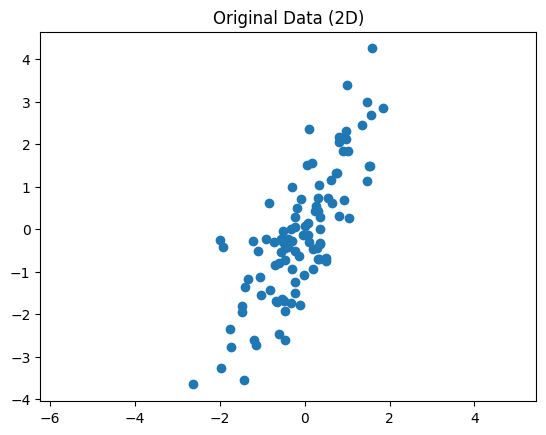

In [12]:
# Visualize raw data
plt.scatter(X[:, 0], X[:, 1])
plt.title("Original Data (2D)")
plt.axis("equal")
plt.show()

In [13]:
# Apply PCA

# 1. center
Xc = X - X.mean(axis=0)

# 2. covariance
C = (Xc.T @ Xc) / len(Xc)

# 3. eigen decomposition
eigvals, eigvecs = np.linalg.eig(C)

# sort
idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]

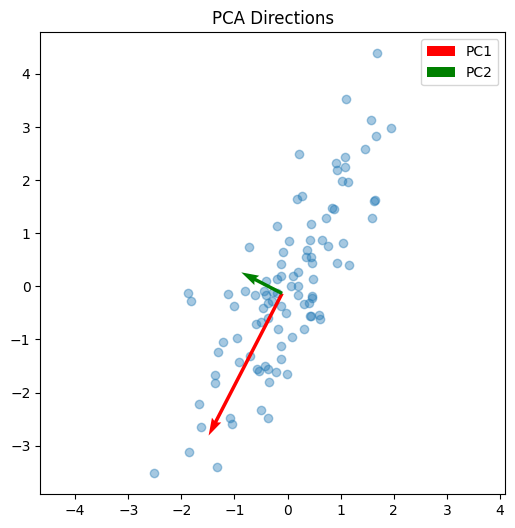

In [14]:
# Plot principal components
plt.figure(figsize=(6, 6))

plt.scatter(Xc[:, 0], Xc[:, 1], alpha=0.4)

origin = X.mean(axis=0)

colors = ['r', 'g']

for i in range(2):
    vec = eigvecs[:, i] * np.sqrt(eigvals[i])
    
    plt.quiver(
        *origin,
        *vec,
        color=colors[i],
        # angles='xy',
        # scale_units='xy',
        scale=5,
        label=f"PC{i+1}"
    )

plt.title("PCA Directions")
plt.axis("equal")
plt.legend()
plt.show()

### Example 2 - 3D dataset (PCA generalization)

In [15]:
# Generate data
np.random.seed(0)

x = np.random.normal(0, 1, 150)
y = 2 * x + np.random.normal(0, 2, 150)
z = 0.5 * x + np.random.normal(0, 2, 150)

X3 = np.column_stack([x, y, z])

In [16]:
# PCA in 3D
Xc = X3 - X3.mean(axis=0)
C = (Xc.T @ Xc) / len(Xc)

eigvals, eigvecs = np.linalg.eig(C)

idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]

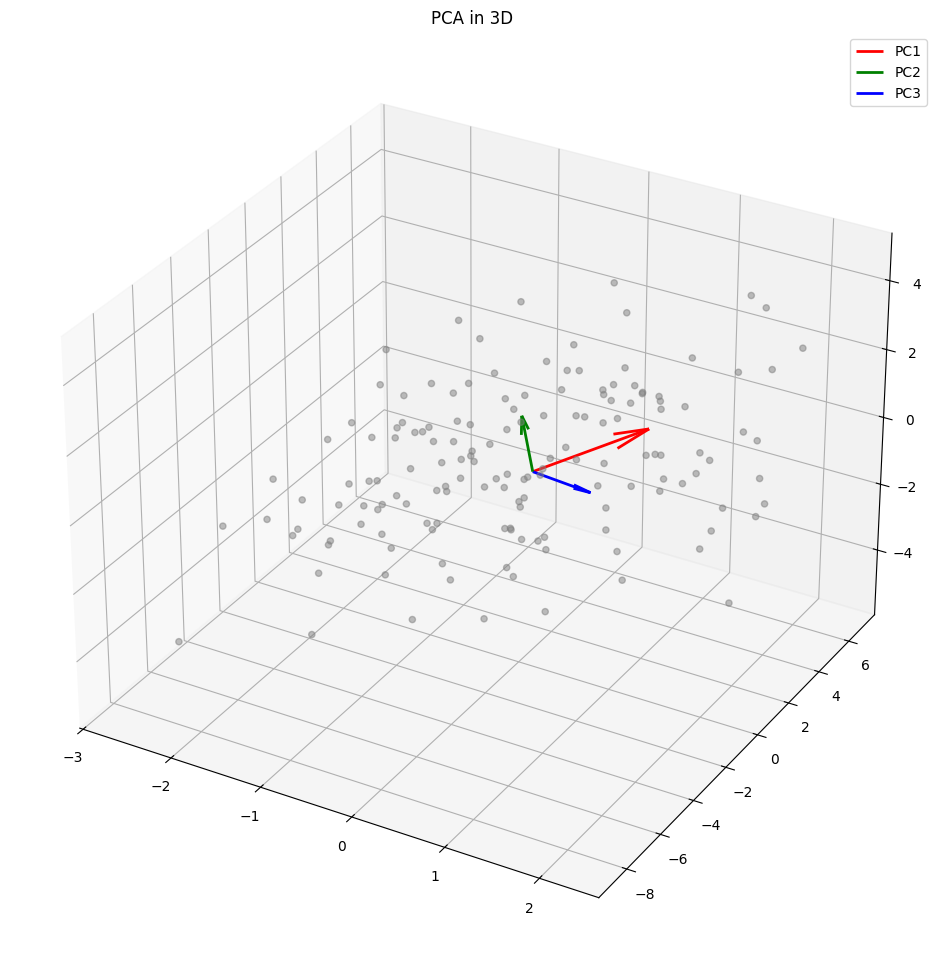

In [17]:
# 3D visualization
fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(Xc[:, 0], Xc[:, 1], Xc[:, 2], alpha=0.5, c='grey')

origin = X3.mean(axis=0)

colors = ['r', 'g', 'b']  # PC1, PC2, PC3

for i in range(3):
    vec = eigvecs[:, i] * np.sqrt(eigvals[i])
    ax.quiver(*origin, *vec, color=colors[i], linewidth=2, label=f"PC{i+1}")

ax.set_title("PCA in 3D")
ax.legend()
plt.show()

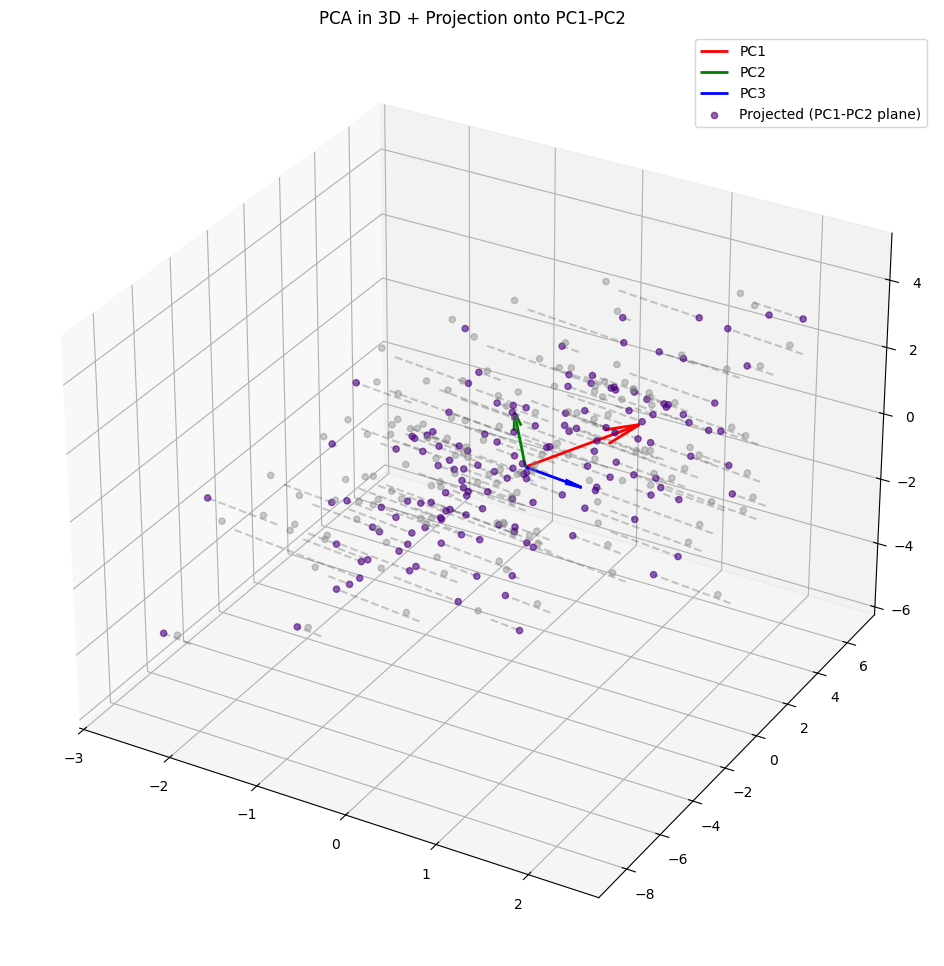

In [18]:
# 3D visualization + projection onto PCA subspace

fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot(111, projection='3d')

# original centered data
ax.scatter(Xc[:, 0], Xc[:, 1], Xc[:, 2], alpha=0.4, c='grey')

origin = X3.mean(axis=0)

colors = ['r', 'g', 'b']  # PC1, PC2, PC3

# --- Step 4: PCA directions ---
for i in range(3):
    vec = eigvecs[:, i] * np.sqrt(eigvals[i])
    ax.quiver(
        *origin,
        *vec,
        color=colors[i],
        linewidth=2,
        label=f"PC{i+1}"
    )

# --- Step 5: projection onto first 2 PCs ---
W = eigvecs[:, :2]          # keep PC1 & PC2
Z = Xc @ W                  # projected 2D data

# reconstruct points back into 3D space (on PCA plane)
X_proj = Z @ W.T + X3.mean(axis=0)

ax.scatter(
    X_proj[:, 0],
    X_proj[:, 1],
    X_proj[:, 2],
    c='indigo',
    alpha=0.6,
    label="Projected (PC1-PC2 plane)"
)

# connect original → projection (optional but very illustrative)
for i in range(len(Xc)):
    ax.plot(
        [X3[i, 0], X_proj[i, 0]],
        [X3[i, 1], X_proj[i, 1]],
        [X3[i, 2], X_proj[i, 2]],
        'k--',
        alpha=0.2
    )

ax.set_title("PCA in 3D + Projection onto PC1-PC2")
ax.legend()
plt.show()